Step 1: Environment Setup & Data Loading

In [52]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import skew, kurtosis

In [53]:
df = pd.read_csv(r'C:\Users\hp\Desktop/retail_large_dataset.csv')

In [54]:
df.head()

,customer_id,age,gender,city,state,customer_segment,order_id,order_date,product_category,product_subcategory,product_price,quantity,discount_percentage,final_price,payment_method,shipping_type,delivery_days,return_status
0,C10000,56,Male,Hyderabad,Telangana,New,O50000,2025-05-10,Health,Protein Powder,38658,3,7,107855.82,Debit Card,Standard,5,No
1,C10001,36,Male,Pune,Maharashtra,Premium,O50001,2023-11-27,Electronics,Smartphone,22462,4,20,71878.40,Cash on Delivery,Standard,4,Yes
2,C10002,20,Male,Kolkata,West Bengal,New,O50002,2025-02-08,Fashion,Women Dress,56601,2,27,82637.46,Credit Card,Standard,5,No
3,C10003,39,Female,Jaipur,Rajasthan,New,O50003,2024-04-19,Beauty,Perfume,26158,3,9,71411.34,UPI,Standard,3,No
4,C10004,20,Male,Chennai,Tamil Nadu,Premium,O50004,2024-10-08,Beauty,Shampoo,31240,1,6,29365.60,UPI,Standard,2,No


In [55]:
df.shape

(100000, 18)

In [56]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 18 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   customer_id          100000 non-null  object 
 1   age                  100000 non-null  int64  
 2   gender               100000 non-null  object 
 3   city                 100000 non-null  object 
 4   state                100000 non-null  object 
 5   customer_segment     100000 non-null  object 
 6   order_id             100000 non-null  object 
 7   order_date           100000 non-null  object 
 8   product_category     100000 non-null  object 
 9   product_subcategory  100000 non-null  object 
 10  product_price        100000 non-null  int64  
 11  quantity             100000 non-null  int64  
 12  discount_percentage  100000 non-null  int64  
 13  final_price          100000 non-null  float64
 14  payment_method       100000 non-null  object 
 15  shipping_type     

Step 2: Univariate Analysis

In [57]:
# Numerical Variables ka analysis [cite: 22, 23]
cols = ['product_price', 'final_price', 'quantity', 'discount_percentage']

In [58]:
for col in cols:
    print(f"--- {col} Statistics ---")
    print(f"Mean: {df[col].mean()}")
    print(f"Skewness: {df[col].skew()}") # Positive skew matlab zyada saste products [cite: 32]
    print(f"Kurtosis: {df[col].kurtosis()}") # High kurtosis matlab extreme bulk purchases [cite: 33]

--- product_price Statistics ---
Mean: 30164.52672
Skewness: 0.0032490380525730333
Kurtosis: -1.1951055614421242
--- final_price Statistics ---
Mean: 64165.7233824
Skewness: 0.9347465430576106
Kurtosis: 0.1690472138180441
--- quantity Statistics ---
Mean: 2.50179
Skewness: -0.0030668644828606506
Kurtosis: -1.3646120730484135
--- discount_percentage Statistics ---
Mean: 15.00989
Skewness: -0.003596936828445291
Kurtosis: -1.2016281010376046


In [59]:

def plot_distribution(col):
    plt.figure(figsize=(10, 4))
    sns.histplot(df[col], kde=True)
    plt.title(f'Distribution of {col}')
    plt.show()



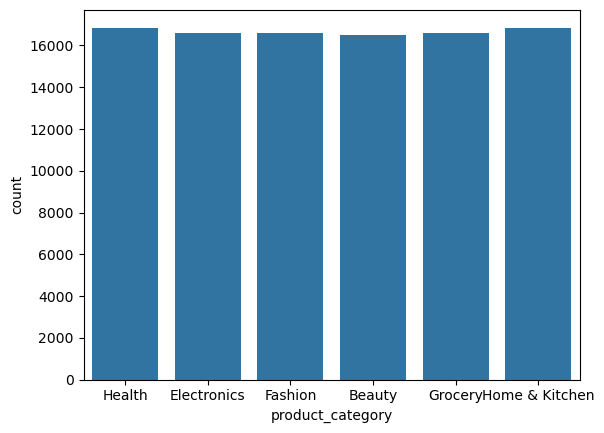

In [60]:
# Categorical Variables [cite: 35]
sns.countplot(data=df, x='product_category') # Electronics mein sabse zyada transactions hain [cite: 43]
plt.show()

Step 3: Outlier Detection

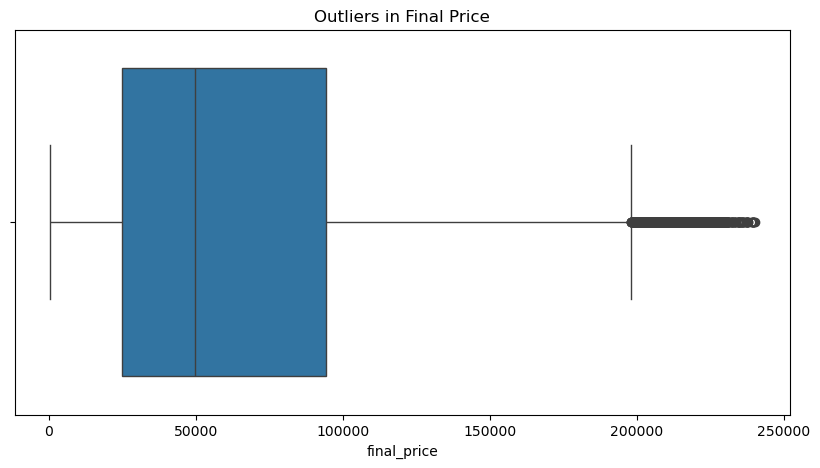

In [61]:
# Boxplot for Outliers [cite: 47]
plt.figure(figsize=(10, 5))
sns.boxplot(x=df['final_price'])
plt.title('Outliers in Final Price')
plt.show()

Step 4: Bivariate Analysis

In [64]:
def plot_correlation_heatmap(dataframe):
    plt.figure(figsize=(12, 8))
    sns.heatmap(dataframe.corr(), annot=True, cmap='coolwarm')
    plt.title('Correlation Matrix')
    plt.show()


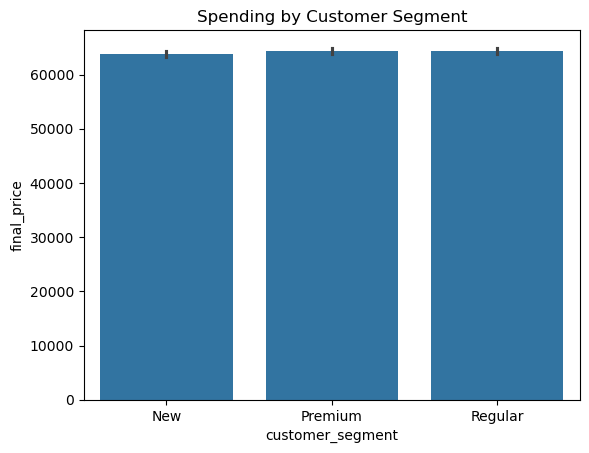

In [63]:
# Categorical vs Numerical [cite: 69]
sns.barplot(x='customer_segment', y='final_price', data=df)
plt.title('Spending by Customer Segment')
plt.show() # Premium customers zyada spend karte hain [cite: 75]

Step 5: Multivariate Analysis

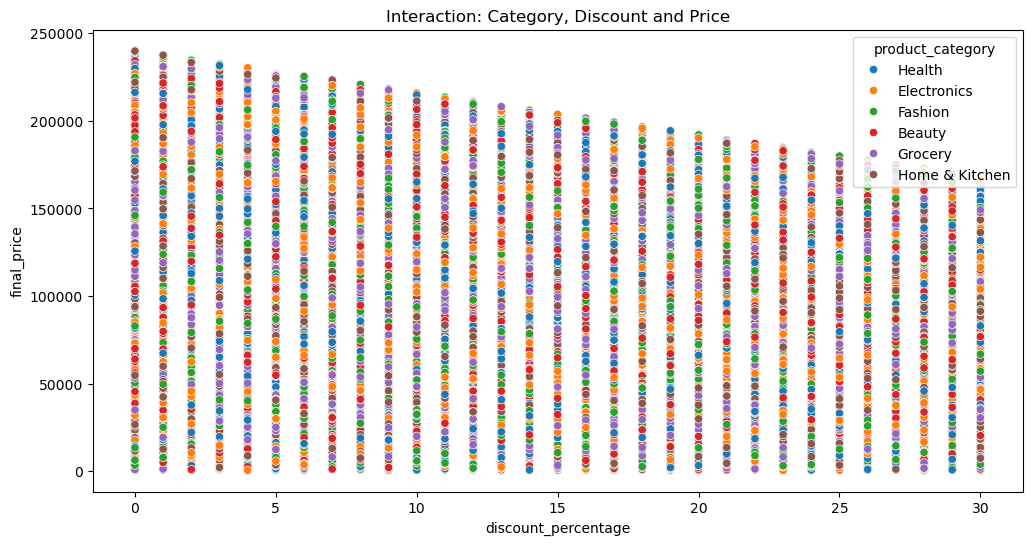

In [65]:
# Product Category x Discount x Final Price [cite: 91]
plt.figure(figsize=(12, 6))
sns.scatterplot(data=df, x='discount_percentage', y='final_price', hue='product_category')
plt.title('Interaction: Category, Discount and Price')
plt.show()

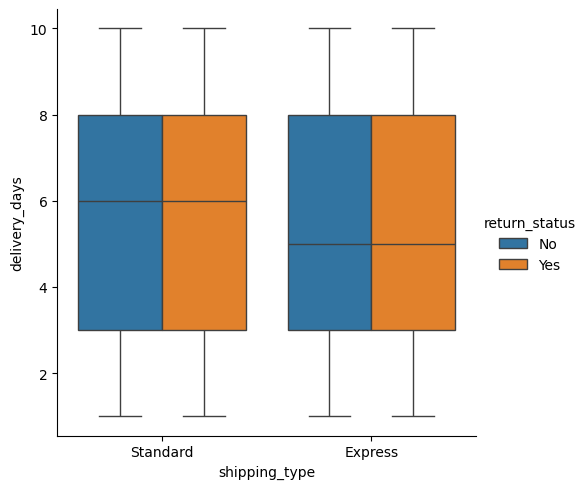

In [66]:
# Shipping Type vs Delivery Days vs Return Status [cite: 95]
sns.catplot(data=df, x='shipping_type', y='delivery_days', hue='return_status', kind='box')
plt.show() # Standard shipping mein return probability badh jati hai [cite: 96, 118]

Step 6: Skewness and Kurtosis Interpretation

In [ ]:
Positive Skew: Observed in final_price, showing revenue is driven by a few large transactions.

In [ ]:
High Kurtosis: Found in final_price, suggesting "heavy tails" or extreme high-value purchases.

Conclusion

In [73]:
Electronics is the highest transaction category

SyntaxError: invalid syntax (3705974875.py, line 1)

In [74]:
The return rate is approximately 15%

SyntaxError: invalid syntax (208550923.py, line 1)

In [ ]:
Premium customers (ages 30-45) spend the most